# Credit Default Risk Classifier

*Librerias*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Obtener el set de datos

*Cargar dataset*

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CS AVANZADAS/Modulo Inteligencia Artificial/Proyecto/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv",)

In [4]:
df.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


*Revisando los datatypes*

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

*Determinar missing values en cada variable*

In [6]:
df.count()

,0
user_id,10345
age,10345
employment_type,10345
monthly_income,10345
credit_score,10345
purchase_amount,10345
product_category,10345
bnpl_installments,10345
repayment_delay_days,10345
missed_payments,10345


In [8]:
print('Columns with null values:', df.isnull().sum(), sep = '\n')

Columns with null values:
user_id                 0
age                     0
employment_type         0
monthly_income          0
credit_score            0
purchase_amount         0
product_category        0
bnpl_installments       0
repayment_delay_days    0
missed_payments         0
default_flag            0
app_usage_frequency     0
location                0
transaction_date        0
debt_to_income_ratio    0
risk_score              0
customer_segment        0
dtype: int64


\
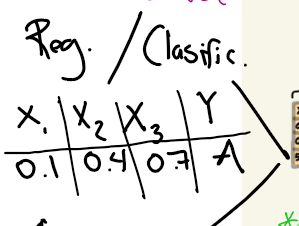

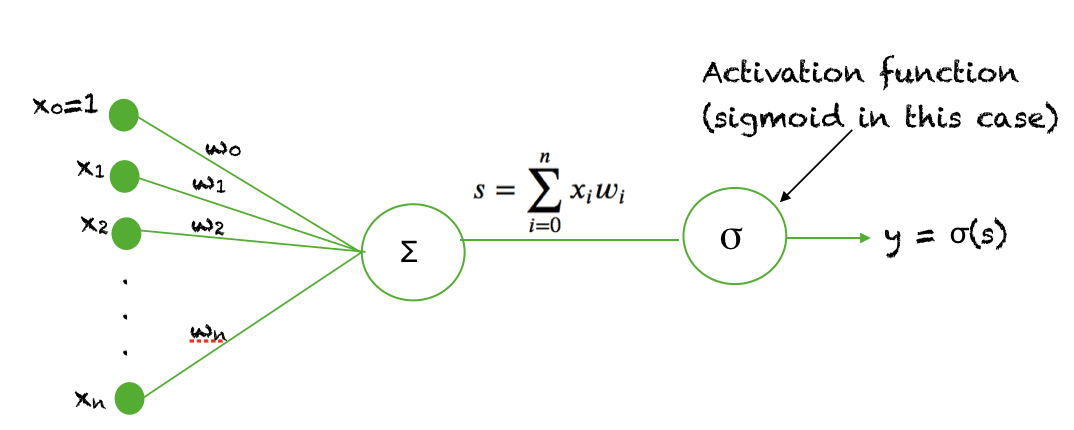

*Limpiar datos: Seleccionar columnas necesarias para determinar features (x) y target (y) y enfocarlo como un modelo de clasificación, usando una regresión logistica (función sigmoid)*


*Para elegir sabiamente las features, me parecio interesante probar con una correlación de Pearson para determinar que tan revelantes son unas variables sobre otras en función de `default_flag`*

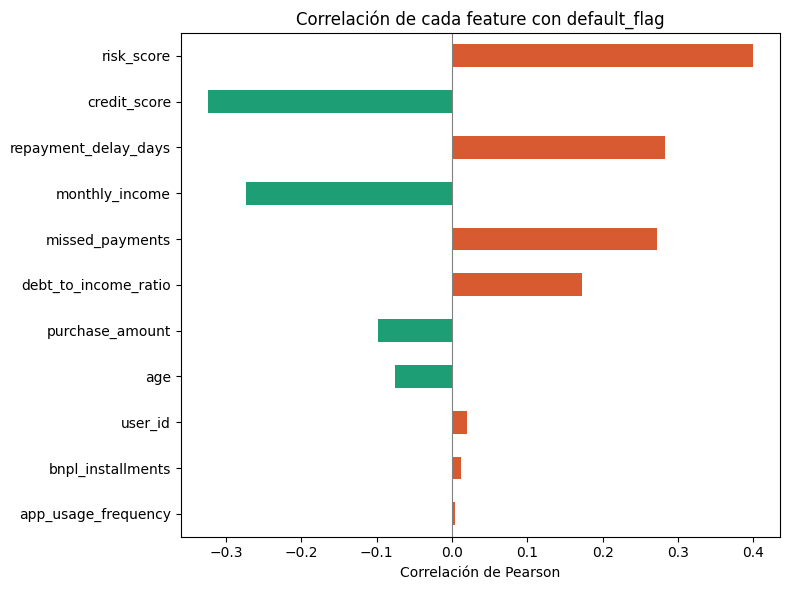

In [9]:
import matplotlib.pyplot as plt

corr_target = df.select_dtypes(include='number') \
                .corr()['default_flag'] \
                .drop('default_flag') \
                .sort_values(key=abs, ascending=True)

colors = ['#D85A30' if v > 0 else '#1D9E75' for v in corr_target]

plt.figure(figsize=(8, 6))
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='gray', linewidth=0.8)
plt.title('Correlación de cada feature con default_flag')
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

In [11]:
x_values = df[['risk_score', 'credit_score', 'repayment_delay_days', 'monthly_income', 'missed_payments']]

In [12]:
x_values

,risk_score,credit_score,repayment_delay_days,monthly_income,missed_payments
0,165.2,552,13,68529.50,1
1,266.0,300,13,7247.85,1
2,229.6,471,19,41582.26,2
3,356.0,300,18,14423.46,5
4,135.2,512,0,42845.50,0
...,...,...,...,...,...
10340,182.8,393,0,17344.34,0
10341,264.0,300,12,17788.20,1
10342,174.0,535,4,59350.25,2
10343,72.8,678,2,73739.74,0


In [13]:
y_target = df['default_flag']

In [14]:
y_target

,default_flag
0,0
1,0
2,0
3,1
4,0
...,...
10340,1
10341,0
10342,0
10343,0


*Como mi target ya esta en binario, no considero necesario realizar el Label Encoder*

## Split de train y test set

In [16]:
n_samples = len(x_values)
shuffled_indices = np.random.permutation(n_samples)
test_size = int(0.20 * n_samples)

In [17]:
# Sacar indices para test y train
test_indices = shuffled_indices[:test_size]
train_indices = shuffled_indices[test_size:]

# Split de data usando los indices generados
X_train = x_values.iloc[train_indices]
X_test = x_values.iloc[test_indices]
y_train = y_target.iloc[train_indices]
y_test = y_target.iloc[test_indices]

print(f"Tamaño del set de entrenamiento (X): {X_train.shape}")
print(f"Tamaño del set de prueba (X): {X_test.shape}")
print(f"Tamaño del set de entrenamiento (y): {y_train.shape}")
print(f"Tamaño del set de prueba (y): {y_test.shape}")

Tamaño del set de entrenamiento (X): (8276, 5)
Tamaño del set de prueba (X): (2069, 5)
Tamaño del set de entrenamiento (y): (8276,)
Tamaño del set de prueba (y): (2069,)


## Preprocesado de datos

### Técnica de escalamiento

*Realizar un escalamiento de las features ya que hay algunas que tienen valores muy altas y puede causar sesgos*

*Tecnica: Standardization*

\(x - μ) / σ

Donde μ es la media y σ es la desviación estándar. El resultado es que cada valor queda expresado en terminos de cuántas desviaciones estándar está alejado de la media

In [18]:
X_train_arr = X_train.values.astype(np.float32)
X_test_arr  = X_test.values.astype(np.float32)

# Calcular media y std solo para train
mean = X_train_arr.mean(axis=0)
std  = X_train_arr.std(axis=0)

# Aplicar a ambos
X_train_scaled = (X_train_arr - mean) / std
X_test_scaled  = (X_test_arr  - mean) / std  # usa la media/std del train


In [19]:
X_train_scaled

array([[ 1.2407533 , -0.65562254,  0.61454535, -0.05641548,  1.9839057 ],
       [-2.0286555 ,  1.8132676 , -1.2927878 ,  1.4566864 , -1.0204499 ],
       [ 1.5072812 , -0.5823617 ,  2.2284427 ,  0.34205508,  1.9839057 ],
       ...,
       [-1.1046921 ,  1.4762677 ,  0.4678274 ,  1.6910024 , -0.01899803],
       [-2.733474  ,  2.7583323 , -0.999352  ,  2.4373093 , -1.0204499 ],
       [ 0.7373119 , -0.9852963 , -0.26576227, -0.96586406, -0.01899803]],
      dtype=float32)